In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

<frozen importlib._bootstrap>:488: Warning: Numpy built with MINGW-W64 on Windows 64 bits is experimental, and only available for 
testing. You are advised not to use it for production. 

CRASHES ARE TO BE EXPECTED - PLEASE REPORT THEM TO NUMPY DEVELOPERS


: 

In [43]:
df = pd.read_csv("laptop_clean_dataset.csv")

In [44]:
df.head()

,Company,TypeName,Inches,Weight,screen_resolution,display_type,processor_speed,processor_brand,processor_type,ssd_storage,hdd_storage,flash_storage,ram,os,Price
0,Apple,Ultrabook,13.3,1.37,2560x1600,Quad HD,2.3,Intel,Core i5,128,0,0,8,macos,71378.6832
1,Apple,Ultrabook,13.3,1.34,1440x900,HD,1.8,Intel,Core i5,0,0,128,8,macos,47895.5232
2,HP,Notebook,15.6,1.86,1920x1080,Full HD,2.5,Intel,Core i5 7200U,256,0,0,8,no,30636.0000
3,Apple,Ultrabook,15.4,1.83,2880x1800,Quad HD,2.7,Intel,Core i7,512,0,0,16,macos,135195.3360
4,Apple,Ultrabook,13.3,1.37,2560x1600,Quad HD,3.1,Intel,Core i5,256,0,0,8,macos,96095.8080


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Company            1243 non-null   object 
 1   TypeName           1243 non-null   object 
 2   Inches             1243 non-null   float64
 3   Weight             1243 non-null   object 
 4   screen_resolution  1243 non-null   object 
 5   display_type       1243 non-null   object 
 6   processor_speed    1243 non-null   float64
 7   processor_brand    1243 non-null   object 
 8   processor_type     1243 non-null   object 
 9   ssd_storage        1243 non-null   int64  
 10  hdd_storage        1243 non-null   object 
 11  flash_storage      1243 non-null   int64  
 12  ram                1243 non-null   int64  
 13  os                 1243 non-null   object 
 14  Price              1243 non-null   float64
dtypes: float64(3), int64(3), object(9)
memory usage: 145.8+ KB


In [46]:
pd.set_option('display.max_rows', None)

In [47]:
def frequency(data):
    freq = data.value_counts()
    return freq

In [48]:
# remove the 201 index (that laptop has missing weight)
df.drop(201, inplace=True)

In [49]:
df[df['Weight'] == '?']

,Company,TypeName,Inches,Weight,screen_resolution,display_type,processor_speed,processor_brand,processor_type,ssd_storage,hdd_storage,flash_storage,ram,os,Price


In [50]:
# change the dtype
df['Weight'] = df['Weight'].astype(float)

In [51]:
# convert 1TB = 1024GB for display purposes
df['hdd_storage'] = df['hdd_storage'].str.replace('1TB', '1024').str.replace('2TB', '2048').str.replace('1024 1024', '1024').str.replace('0TB','0').astype(int)

In [52]:
df['hdd_storage'] = df['hdd_storage'].astype(int)

In [53]:
cat_columns = df.select_dtypes(['object', 'category']).columns
for column in cat_columns:

    frequency(df[column])

In [54]:
def frequency(series):
    print(f"\n{'='*45}")
    print(f"Column: {series.name}")
    print(f"{'='*45}")
    print(series.value_counts())
    print(f"Unique values: {series.nunique()}")

cat_columns = df.select_dtypes(['object', 'category']).columns
for column in cat_columns:
    frequency(df[column])


Column: Company
Company
Lenovo       281
Dell         280
HP           260
Asus         149
Acer         105
MSI           53
Toshiba       47
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Xiaomi         4
Chuwi          3
LG             3
Google         3
Huawei         2
Fujitsu        2
Name: count, dtype: int64
Unique values: 18

Column: TypeName
TypeName
Notebook              711
Gaming                203
Ultrabook             188
2 in 1 Convertible    111
Workstation            29
Name: count, dtype: int64
Unique values: 5

Column: screen_resolution
screen_resolution
1920x1080    813
1366x768     282
3840x2160     42
3200x1800     24
1600x900      23
2560x1440     22
2304x1440      6
2560x1600      6
2256x1504      6
2880x1800      4
1440x900       4
2400x1600      4
1920x1200      3
2160x1440      2
2736x1824      1
Name: count, dtype: int64
Unique values: 15

Column: display_type
display_type
Full HD    834
HD         309
Quad HD     57
4

In [55]:
df.select_dtypes(['object', 'category']).head()

,Company,TypeName,screen_resolution,display_type,processor_brand,processor_type,os
0,Apple,Ultrabook,2560x1600,Quad HD,Intel,Core i5,macos
1,Apple,Ultrabook,1440x900,HD,Intel,Core i5,macos
2,HP,Notebook,1920x1080,Full HD,Intel,Core i5 7200U,no
3,Apple,Ultrabook,2880x1800,Quad HD,Intel,Core i7,macos
4,Apple,Ultrabook,2560x1600,Quad HD,Intel,Core i5,macos


In [56]:
# ══════════════════════════════════════════════════════════════════
# STEP 1 — CHECK BEFORE DOING ANYTHING
# ══════════════════════════════════════════════════════════════════
cat_cols = df.select_dtypes(['object', 'category']).columns.tolist()

print("=" * 55)
print("  CATEGORICAL COLUMNS — PRE-PROCESSING INSPECTION")
print("=" * 55)
print(f"\nFound {len(cat_cols)} categorical columns: {cat_cols}")

print("\n── Missing Values ───────────────────────────────────────")
for col in cat_cols:
    miss = df[col].isnull().sum()
    pct  = miss / len(df) * 100
    print(f"  {col:<25} missing: {miss:>4}  ({pct:.1f}%)")

print("\n── Unique Value Counts ──────────────────────────────────")
for col in cat_cols:
    print(f"  {col:<25} unique: {df[col].nunique()}")

  CATEGORICAL COLUMNS — PRE-PROCESSING INSPECTION

Found 7 categorical columns: ['Company', 'TypeName', 'screen_resolution', 'display_type', 'processor_brand', 'processor_type', 'os']

── Missing Values ───────────────────────────────────────
  Company                   missing:    0  (0.0%)
  TypeName                  missing:    0  (0.0%)
  screen_resolution         missing:    0  (0.0%)
  display_type              missing:    0  (0.0%)
  processor_brand           missing:    0  (0.0%)
  processor_type            missing:    0  (0.0%)
  os                        missing:    0  (0.0%)

── Unique Value Counts ──────────────────────────────────
  Company                   unique: 18
  TypeName                  unique: 5
  screen_resolution         unique: 15
  display_type              unique: 4
  processor_brand           unique: 3
  processor_type            unique: 93
  os                        unique: 6


In [57]:
# ══════════════════════════════════════════════════════════════════
# STEP 2 — CUSTOM TRANSFORMERS
# ══════════════════════════════════════════════════════════════════

# ── Transformer A: Rare Category Grouper ─────────────────────────
# Used for: Company (18 unique, many with <10 rows)
# Logic: any category with count < threshold → replaced with 'Other'

class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """
    Groups rare categories (count < threshold) into 'Other'.
    Fit on training data only to prevent data leakage.

    Example:
        Company: Samsung(9), Mediacom(7), Razer(7) ... → 'Other'
        Keeps : Lenovo(281), Dell(280), HP(260), Asus(149),
                Acer(105), MSI(53), Toshiba(47), Apple(21)
    """
    def __init__(self, threshold=10):
        self.threshold = threshold
        self.frequent_categories_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        for col in X.columns:
            counts = X[col].value_counts()
            self.frequent_categories_[col] = set(
                counts[counts >= self.threshold].index
            )
            rare = counts[counts < self.threshold]
            print(f"\n  [RareCategoryGrouper] '{col}' — threshold={self.threshold}")
            print(f"    Kept  : {sorted(self.frequent_categories_[col])}")
            if len(rare) > 0:
                print(f"    Rare→Other: {sorted(rare.index.tolist())} "
                      f"({len(rare)} categories)")
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            freq = self.frequent_categories_.get(col, set())
            X[col] = X[col].apply(
                lambda v: v if v in freq else 'Other'
            )
        return X.values

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.array(input_features)
        return np.array([f"col_{i}"
                         for i in range(len(self.frequent_categories_))])


In [58]:
# ── Transformer B: OS Standardiser ───────────────────────────────
# Used for: os (6 unique — mac + macos are duplicates)
# Logic:  mac & macos → macOS, all others standardised
class OSStandardiser(BaseEstimator, TransformerMixin):
    """
    Fixes duplicate OS labels before encoding.

    Your data:
        windows(1074), no(63), linux(57),
        chrome(27), macos(13), mac(8)

    After:
        Windows(1074), No OS(63), Linux(57),
        Chrome OS(27), macOS(21)   ← mac+macos merged
    """
    OS_MAP = {
        'macos':   'macOS',
        'mac':     'macOS',
        'windows': 'Windows',
        'linux':   'Linux',
        'chrome':  'Chrome OS',
        'no':      'No OS',
    }

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = (X[col].astype(str)
                            .str.lower()
                            .str.strip()
                            .map(self.OS_MAP)
                            .fillna('Other'))
        return X.values

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.array(input_features)
        return np.array(['os'])

In [59]:
# ── Transformer C: Processor Family Grouper ──────────────────────
# Used for: processor_type (93 unique → 10 families)
# Logic:  group by chip family name
class ProcessorFamilyGrouper(BaseEstimator, TransformerMixin):
    """
    Reduces processor_type from 93 unique values → 10 families.

    Your data examples:
        'Core i5 7200U'(186), 'Core i7 7700HQ'(143) ... → 'Core i7'
        'Celeron Dual Core N3350'(33)                   → 'Celeron'
        'A9-Series 9420'(12), 'FX 9830P'(1)            → 'AMD Other'
        'Cortex A72&A53'(1)                             → 'Other'
    """
    @staticmethod
    def _group(proc):
        p = str(proc).lower()
        if 'core i9'  in p: return 'Core i9'
        if 'core i7'  in p: return 'Core i7'
        if 'core i5'  in p: return 'Core i5'
        if 'core i3'  in p: return 'Core i3'
        if 'core m'   in p: return 'Core M'
        if 'ryzen'    in p: return 'Ryzen'
        if 'xeon'     in p: return 'Xeon'
        if 'celeron'  in p: return 'Celeron'
        if 'pentium'  in p: return 'Pentium'
        if 'atom'     in p: return 'Atom'
        if any(x in p for x in [
            'a4-','a6-','a8-','a9-','a10-','a12-',
            'a4 ','a6 ','a8 ','a9 ','a10 ','a12 ',
            'fx ', 'e-series']):
            return 'AMD Other'
        return 'Other'

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            before = X[col].nunique()
            X[col] = X[col].apply(self._group)
            after  = X[col].nunique()
            print(f"\n  [ProcessorFamilyGrouper] '{col}': "
                  f"{before} unique → {after} families")
            print(f"    Families: {sorted(X[col].unique().tolist())}")
        return X.values

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.array(input_features)
        return np.array(['processor_type'])


In [60]:
# ══════════════════════════════════════════════════════════════════
# STEP 3 — DEFINE COLUMN GROUPS
# (based on your actual frequency data)
# ══════════════════════════════════════════════════════════════════

# ── display_type — ORDINAL ────────────────────────────────────────
# Unique: 4  |  Full HD(834), HD(309), Quad HD(57), 4K(42)
# Clear quality hierarchy → Ordinal encoding
# HD=1, Full HD=2, Quad HD=3, 4K=4
ordinal_cols     = ['display_type']
ordinal_cats     = [['HD', 'Full HD', 'Quad HD', '4K']]

# ── Company — RARE GROUP + OHE ────────────────────────────────────
# Unique: 18  |  8 brands ≥ 10 rows, 10 brands < 10 → 'Other'
# Rare brands: Samsung(9), Mediacom(7), Razer(7), Microsoft(6),
#              Xiaomi(4), Chuwi(3), LG(3), Google(3), Huawei(2), Fujitsu(2)
company_cols     = ['Company']

# ── TypeName — OHE (no rare issue) ───────────────────────────────
# Unique: 5  |  Notebook(711), Gaming(203), Ultrabook(188),
#              2in1(111), Workstation(29)  ← all well represented
typename_cols    = ['TypeName']

# ── screen_resolution — DROP (extract pixels separately later) ────
# Unique: 15  |  will be parsed into total_pixels + ppi
# Kept here as passthrough for now, numeric step will handle it
# screen_resolution_cols = ['screen_resolution']  # ← handle in numeric step

# ── processor_brand — OHE (rare group Samsung) ───────────────────
# Unique: 3  |  Intel(1181), AMD(60), Samsung(1) → Samsung rare
proc_brand_cols  = ['processor_brand']

# ── processor_type — FAMILY GROUP + OHE ──────────────────────────
# Unique: 93  |  93 → 10 families
proc_type_cols   = ['processor_type']

# ── os — STANDARDISE + OHE ───────────────────────────────────────
# Unique: 6  |  mac(8)+macos(13) are duplicates → merge to macOS
os_cols          = ['os']

print("\n── Column encoding strategy ────────────────────────────")
print(f"  Ordinal (HD→4K)       : {ordinal_cols}")
print(f"  Rare+OHE (thresh=10)  : {company_cols}")
print(f"  OHE only              : {typename_cols}")
print(f"  Rare+OHE (thresh=10)  : {proc_brand_cols}")
print(f"  Family+OHE (93→10)   : {proc_type_cols}")
print(f"  Standardise+OHE       : {os_cols}")



── Column encoding strategy ────────────────────────────
  Ordinal (HD→4K)       : ['display_type']
  Rare+OHE (thresh=10)  : ['Company']
  OHE only              : ['TypeName']
  Rare+OHE (thresh=10)  : ['processor_brand']
  Family+OHE (93→10)   : ['processor_type']
  Standardise+OHE       : ['os']


In [61]:
# ══════════════════════════════════════════════════════════════════
# STEP 4 — BUILD INDIVIDUAL PIPELINES
# ══════════════════════════════════════════════════════════════════

# ── Pipeline A: display_type → Ordinal ───────────────────────────
display_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=ordinal_cats,
        handle_unknown='use_encoded_value',
        unknown_value=np.nan
    )),
])

# ── Pipeline B: Company → Rare Group → OHE ───────────────────────
company_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('rare',    RareCategoryGrouper(threshold=10)),
    ('ohe',     OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        drop='first'
    )),
])

# ── Pipeline C: TypeName → OHE ───────────────────────────────────
typename_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        drop='first'
    )),
])

# ── Pipeline D: processor_brand → Rare Group → OHE ───────────────
proc_brand_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('rare',    RareCategoryGrouper(threshold=10)),
    ('ohe',     OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        drop='first'
    )),
])

# ── Pipeline E: processor_type → Family → OHE ────────────────────
proc_type_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('family',  ProcessorFamilyGrouper()),
    ('ohe',     OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        drop='first'
    )),
])

# ── Pipeline F: os → Standardise → OHE ──────────────────────────
os_pipeline = Pipeline(steps=[
    ('imputer',      SimpleImputer(strategy='most_frequent')),
    ('standardise',  OSStandardiser()),
    ('ohe',          OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        drop='first'
    )),
])


In [62]:
# ══════════════════════════════════════════════════════════════════
# STEP 5 — COLUMN TRANSFORMER (combines all pipelines)
# ══════════════════════════════════════════════════════════════════
categorical_preprocessor = ColumnTransformer(
    transformers=[
        ('display',    display_pipeline,    ordinal_cols),
        ('company',    company_pipeline,    company_cols),
        ('typename',   typename_pipeline,   typename_cols),
        ('proc_brand', proc_brand_pipeline, proc_brand_cols),
        ('proc_type',  proc_type_pipeline,  proc_type_cols),
        ('os',         os_pipeline,         os_cols),
    ],
    remainder='passthrough',        # keeps numeric cols untouched for now
    verbose_feature_names_out=True
)

In [63]:
# ══════════════════════════════════════════════════════════════════
# STEP 6 — FIT & TRANSFORM
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  FITTING PIPELINE")
print("=" * 55)

X = df.drop(columns=['Price'])   # drop target
y = df['Price']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print("\n── Fitting on training data only (no leakage) ───────────")

X_train_transformed = categorical_preprocessor.fit_transform(X_train)
X_test_transformed  = categorical_preprocessor.transform(X_test)

print("\n── Shape After Transformation ───────────────────────────")
print(f"  X_train : {X_train.shape} → {X_train_transformed.shape}")
print(f"  X_test  : {X_test.shape}  → {X_test_transformed.shape}")



  FITTING PIPELINE

Train: (993, 14)  |  Test: (249, 14)

── Fitting on training data only (no leakage) ───────────

  [RareCategoryGrouper] '0' — threshold=10
    Kept  : ['Acer', 'Apple', 'Asus', 'Dell', 'HP', 'Lenovo', 'MSI', 'Toshiba']
    Rare→Other: ['Chuwi', 'Fujitsu', 'Google', 'Huawei', 'LG', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Xiaomi'] (10 categories)

  [RareCategoryGrouper] '0' — threshold=10
    Kept  : ['AMD', 'Intel']
    Rare→Other: ['Samsung'] (1 categories)

  [ProcessorFamilyGrouper] '0': 88 unique → 11 families
    Families: ['AMD Other', 'Atom', 'Celeron', 'Core M', 'Core i3', 'Core i5', 'Core i7', 'Other', 'Pentium', 'Ryzen', 'Xeon']

  [ProcessorFamilyGrouper] '0': 46 unique → 8 families
    Families: ['AMD Other', 'Atom', 'Celeron', 'Core M', 'Core i3', 'Core i5', 'Core i7', 'Pentium']

── Shape After Transformation ───────────────────────────
  X_train : (993, 14) → (993, 37)
  X_test  : (249, 14)  → (249, 37)


In [64]:
# ══════════════════════════════════════════════════════════════════
# STEP 7 — INSPECT OUTPUT
# ══════════════════════════════════════════════════════════════════

# Get feature names
feature_names = categorical_preprocessor.get_feature_names_out()

print(f"\n── All Output Feature Names ({len(feature_names)}) ──────────────────")
for i, name in enumerate(feature_names, 1):
    print(f"  {i:>3}. {name}")

# Convert to DataFrame for easy inspection
X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_transformed,  columns=feature_names)

print("\n── Sample Transformed Training Data (first 3 rows) ─────")
cat_feature_names = [n for n in feature_names
                     if not n.startswith('remainder__')]
print(X_train_df[cat_feature_names].head(3).to_string())

# ══════════════════════════════════════════════════════════════════
# STEP 8 — VERIFY ENCODING RESULTS
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  VERIFICATION")
print("=" * 55)

# display_type ordinal check
disp_col = 'display__display_type'
if disp_col in feature_names:
    vals = X_train_df[disp_col].value_counts().sort_index()
    print(f"\ndisplay_type ordinal values: {sorted(vals.index.tolist())}")
    print("  Expected: [0.0, 1.0, 2.0, 3.0] (HD=0, Full HD=1, Quad HD=2, 4K=3)")

# OS check — confirm mac+macos merged
os_ohe_cols = [c for c in feature_names if c.startswith('os__')]
print(f"\nOS OHE columns created: {os_ohe_cols}")
print("  Expected: 4 columns (5 categories - 1 dropped)")

# Company check — confirm 'Other' created
comp_ohe_cols = [c for c in feature_names if c.startswith('company__')]
print(f"\nCompany OHE columns: {comp_ohe_cols}")
print("  Expected: 8 cols (Lenovo,Dell,HP,Asus,Acer,MSI,Toshiba,Apple,Other - 1 dropped)")

# Processor type check
proc_ohe_cols = [c for c in feature_names if c.startswith('proc_type__')]
print(f"\nProcessor Type OHE columns: {proc_ohe_cols}")
print("  Expected: ~9 cols (10 families - 1 dropped)")



── All Output Feature Names (37) ──────────────────
    1. display__display_type
    2. company__Company_Apple
    3. company__Company_Asus
    4. company__Company_Dell
    5. company__Company_HP
    6. company__Company_Lenovo
    7. company__Company_MSI
    8. company__Company_Other
    9. company__Company_Toshiba
   10. typename__TypeName_Gaming
   11. typename__TypeName_Notebook
   12. typename__TypeName_Ultrabook
   13. typename__TypeName_Workstation
   14. proc_brand__processor_brand_Intel
   15. proc_brand__processor_brand_Other
   16. proc_type__processor_type_Atom
   17. proc_type__processor_type_Celeron
   18. proc_type__processor_type_Core M
   19. proc_type__processor_type_Core i3
   20. proc_type__processor_type_Core i5
   21. proc_type__processor_type_Core i7
   22. proc_type__processor_type_Other
   23. proc_type__processor_type_Pentium
   24. proc_type__processor_type_Ryzen
   25. proc_type__processor_type_Xeon
   26. os__os_Linux
   27. os__os_No OS
   28. os__os_Windo

In [65]:
# ══════════════════════════════════════════════════════════════════
# STEP 9 — FULL PIPELINE SUMMARY
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  CATEGORICAL PIPELINE SUMMARY")
print("=" * 55)

summary = [
    ("display_type",    "4 unique",  "Ordinal",         "HD=0, Full HD=1, Quad HD=2, 4K=3",   "1 col"),
    ("Company",         "18 unique", "Rare+OHE",        "10 rare brands → 'Other'",            "~9 cols"),
    ("TypeName",        "5 unique",  "OHE",             "No rare issue, all ≥29 rows",         "4 cols"),
    ("processor_brand", "3 unique",  "Rare+OHE",        "Samsung(1) → 'Other'",                "2 cols"),
    ("processor_type",  "93 unique", "FamilyGroup+OHE", "93 → 10 families",                    "~9 cols"),
    ("os",              "6 unique",  "Standardise+OHE", "mac+macos → macOS",                   "4 cols"),
]

print(f"\n  {'Column':<20} {'Unique':<12} {'Strategy':<20} {'Key Action':<35} {'Output'}")
print("  " + "-" * 100)
for row in summary:
    print(f"  {row[0]:<20} {row[1]:<12} {row[2]:<20} {row[3]:<35} {row[4]}")

print("\n  ⚠️  screen_resolution → will be handled in NUMERIC step")
print("      (parse WxH → total_pixels, ppi then scale)")
print("\n  ✅  Categorical preprocessing done!")
print("  ➡️  Next step: add numeric pipeline to ColumnTransformer")


  CATEGORICAL PIPELINE SUMMARY

  Column               Unique       Strategy             Key Action                          Output
  ----------------------------------------------------------------------------------------------------
  display_type         4 unique     Ordinal              HD=0, Full HD=1, Quad HD=2, 4K=3    1 col
  Company              18 unique    Rare+OHE             10 rare brands → 'Other'            ~9 cols
  TypeName             5 unique     OHE                  No rare issue, all ≥29 rows         4 cols
  processor_brand      3 unique     Rare+OHE             Samsung(1) → 'Other'                2 cols
  processor_type       93 unique    FamilyGroup+OHE      93 → 10 families                    ~9 cols
  os                   6 unique     Standardise+OHE      mac+macos → macOS                   4 cols

  ⚠️  screen_resolution → will be handled in NUMERIC step
      (parse WxH → total_pixels, ppi then scale)

  ✅  Categorical preprocessing done!
  ➡️  Next step: 

In [66]:
df.select_dtypes(['object', 'category']).head()

,Company,TypeName,screen_resolution,display_type,processor_brand,processor_type,os
0,Apple,Ultrabook,2560x1600,Quad HD,Intel,Core i5,macos
1,Apple,Ultrabook,1440x900,HD,Intel,Core i5,macos
2,HP,Notebook,1920x1080,Full HD,Intel,Core i5 7200U,no
3,Apple,Ultrabook,2880x1800,Quad HD,Intel,Core i7,macos
4,Apple,Ultrabook,2560x1600,Quad HD,Intel,Core i5,macos


In [67]:
df.select_dtypes(['number']).head(5)

,Inches,Weight,processor_speed,ssd_storage,hdd_storage,flash_storage,ram,Price
0,13.3,1.37,2.3,128,0,0,8,71378.6832
1,13.3,1.34,1.8,0,0,128,8,47895.5232
2,15.6,1.86,2.5,256,0,0,8,30636.0000
3,15.4,1.83,2.7,512,0,0,16,135195.3360
4,13.3,1.37,3.1,256,0,0,8,96095.8080


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

In [69]:
NUM_COLS = ['Inches', 'Weight', 'processor_speed',
            'ssd_storage', 'hdd_storage', 'flash_storage', 'ram']
TARGET   = 'Price'


print("=" * 60)
print("  NUMERICAL PREPROCESSING PIPELINE — LAPTOP DATASET")
print("=" * 60)
print(f"\nDataset shape : {df.shape}")

  NUMERICAL PREPROCESSING PIPELINE — LAPTOP DATASET

Dataset shape : (1242, 15)


In [70]:
# ══════════════════════════════════════════════════════════════════
# STEP 1 — INSPECT
# ══════════════════════════════════════════════════════════════════
print("\n" + "─"*60)
print("  STEP 1: INSPECTION")
print("─"*60)

print("\n── Descriptive Stats ────────────────────────────────────")
print(df[NUM_COLS + [TARGET]].describe().round(2).to_string())

print("\n── Missing Values ───────────────────────────────────────")
for col in NUM_COLS + [TARGET]:
    miss = df[col].isnull().sum()
    print(f"  {col:<22} missing: {miss:>4}  ({miss/len(df)*100:.1f}%)")



────────────────────────────────────────────────────────────
  STEP 1: INSPECTION
────────────────────────────────────────────────────────────

── Descriptive Stats ────────────────────────────────────
        Inches   Weight  processor_speed  ssd_storage  hdd_storage  flash_storage      ram      Price
count  1242.00  1242.00           1242.0      1242.00      1242.00        1242.00  1242.00    1242.00
mean     15.01     2.06              2.3       172.72       423.13           4.50     8.45   60618.11
std       1.45     0.74              0.5       161.38       529.86          30.78     5.12   37441.24
min       9.45     0.69              0.9         0.00         0.00           0.00     2.00    9270.72
25%      14.00     1.50              2.0         0.00         0.00           0.00     4.00   32673.96
50%      15.60     2.04              2.5       180.00         0.00           0.00     8.00   52693.92
75%      15.60     2.32              2.7       256.00      1024.00           0.00  

In [71]:
# ══════════════════════════════════════════════════════════════════
# STEP 2 — OUTLIER DETECTION REPORT
# ══════════════════════════════════════════════════════════════════
print("\n" + "─"*60)
print("  STEP 2: OUTLIER DETECTION")
print("─"*60)

def iqr_report(df, cols):
    rows = []
    for col in cols:
        s = df[col].dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR    = Q3 - Q1
        lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n_out  = ((s < lo) | (s > hi)).sum()
        rows.append({
            'Column':      col,
            'Q1':          round(Q1, 2),
            'Q3':          round(Q3, 2),
            'Lower_Fence': round(lo, 2),
            'Upper_Fence': round(hi, 2),
            'Outliers':    n_out,
            'Outlier_%':   round(n_out / len(s) * 100, 2)
        })
    return pd.DataFrame(rows)

print("\n── IQR Outlier Report ───────────────────────────────────")
print(iqr_report(df, NUM_COLS + [TARGET]).to_string(index=False))

print("\n── Z-Score Outlier Report (|z| > 3) ────────────────────")
for col in NUM_COLS + [TARGET]:
    s     = df[col].dropna()
    n_out = (np.abs(scipy_stats.zscore(s)) > 3).sum()
    print(f"  {col:<22}: {n_out:>4} outliers  ({n_out/len(s)*100:.2f}%)")


────────────────────────────────────────────────────────────
  STEP 2: OUTLIER DETECTION
────────────────────────────────────────────────────────────

── IQR Outlier Report ───────────────────────────────────
         Column       Q1       Q3  Lower_Fence  Upper_Fence  Outliers  Outlier_%
         Inches    14.00    15.60        11.60        18.00        37       2.98
         Weight     1.50     2.32         0.27         3.55        49       3.95
processor_speed     2.00     2.70         0.95         3.75         2       0.16
    ssd_storage     0.00   256.00      -384.00       640.00         0       0.00
    hdd_storage     0.00  1024.00     -1536.00      2560.00         0       0.00
  flash_storage     0.00     0.00         0.00         0.00        68       5.48
            ram     4.00     8.00        -2.00        14.00       213      17.15
          Price 32673.96 79813.44    -38035.26    150522.66        28       2.25

── Z-Score Outlier Report (|z| > 3) ────────────────────
  I

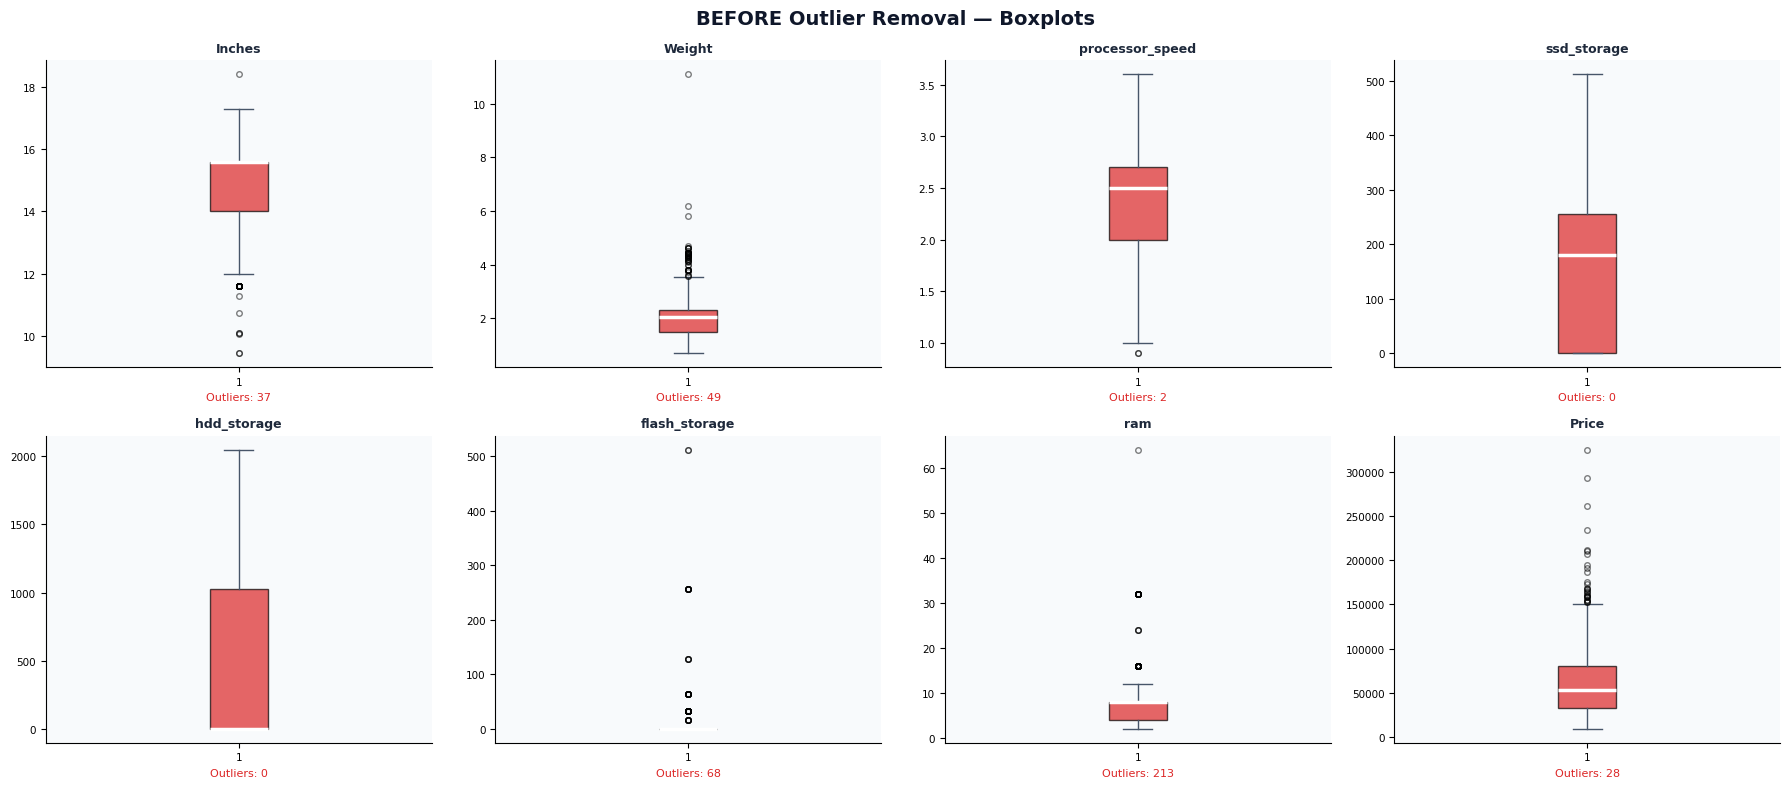


✅ Saved: boxplots_before_num.png


In [72]:
# ══════════════════════════════════════════════════════════════════
# STEP 3 — BOXPLOTS BEFORE REMOVAL
# ══════════════════════════════════════════════════════════════════
all_cols = NUM_COLS + [TARGET]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    s      = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((s < Q1-1.5*IQR) | (s > Q3+1.5*IQR)).sum()

    axes[i].boxplot(s, patch_artist=True,
                    boxprops=dict(facecolor='#DC2626', alpha=0.7),
                    medianprops=dict(color='white', lw=2.5),
                    flierprops=dict(marker='o', markersize=4,
                                    alpha=0.5, color='#1E293B'),
                    whiskerprops=dict(color='#475569'),
                    capprops=dict(color='#475569'))
    axes[i].set_title(col, fontweight='bold', fontsize=9, color='#1E293B')
    axes[i].set_facecolor('#F8FAFC')
    axes[i].spines[['top','right']].set_visible(False)
    axes[i].tick_params(labelsize=7.5)
    axes[i].set_xlabel(f"Outliers: {n_out}", fontsize=8, color='#DC2626')

fig.suptitle('BEFORE Outlier Removal — Boxplots',
             fontsize=14, fontweight='bold', color='#0F172A')
plt.tight_layout()
# plt.savefig('boxplots_before_num.png', dpi=130,
#             bbox_inches='tight', facecolor='#F1F5F9')
plt.show()
print("\n✅ Saved: boxplots_before_num.png")

In [73]:
# ══════════════════════════════════════════════════════════════════
# STEP 4 — TRAIN / TEST SPLIT  (split BEFORE outlier removal)
# ══════════════════════════════════════════════════════════════════
print("\n" + "─"*60)
print("  STEP 4: TRAIN / TEST SPLIT")
print("─"*60)

X = df[NUM_COLS].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n  X_train : {X_train.shape}  |  X_test : {X_test.shape}")


────────────────────────────────────────────────────────────
  STEP 4: TRAIN / TEST SPLIT
────────────────────────────────────────────────────────────

  X_train : (993, 7)  |  X_test : (249, 7)



────────────────────────────────────────────────────────────
  STEP 5: OUTLIER REMOVAL (IQR — train only, drop rows)
────────────────────────────────────────────────────────────

  Rows before : 993
  Rows after  : 744
  Removed     : 249  (25.1% of train)

  IQR Bounds used (fitted on train only):
    Inches                : [     11.60,       18.00]
    Weight                : [      0.27,        3.55]
    processor_speed       : [      0.95,        3.75]
    ssd_storage           : [   -384.00,      640.00]
    hdd_storage           : [  -1536.00,     2560.00]
    flash_storage         : [      0.00,        0.00]
    ram                   : [     -2.00,       14.00]
    Price                 : [ -37350.61,   150197.12]


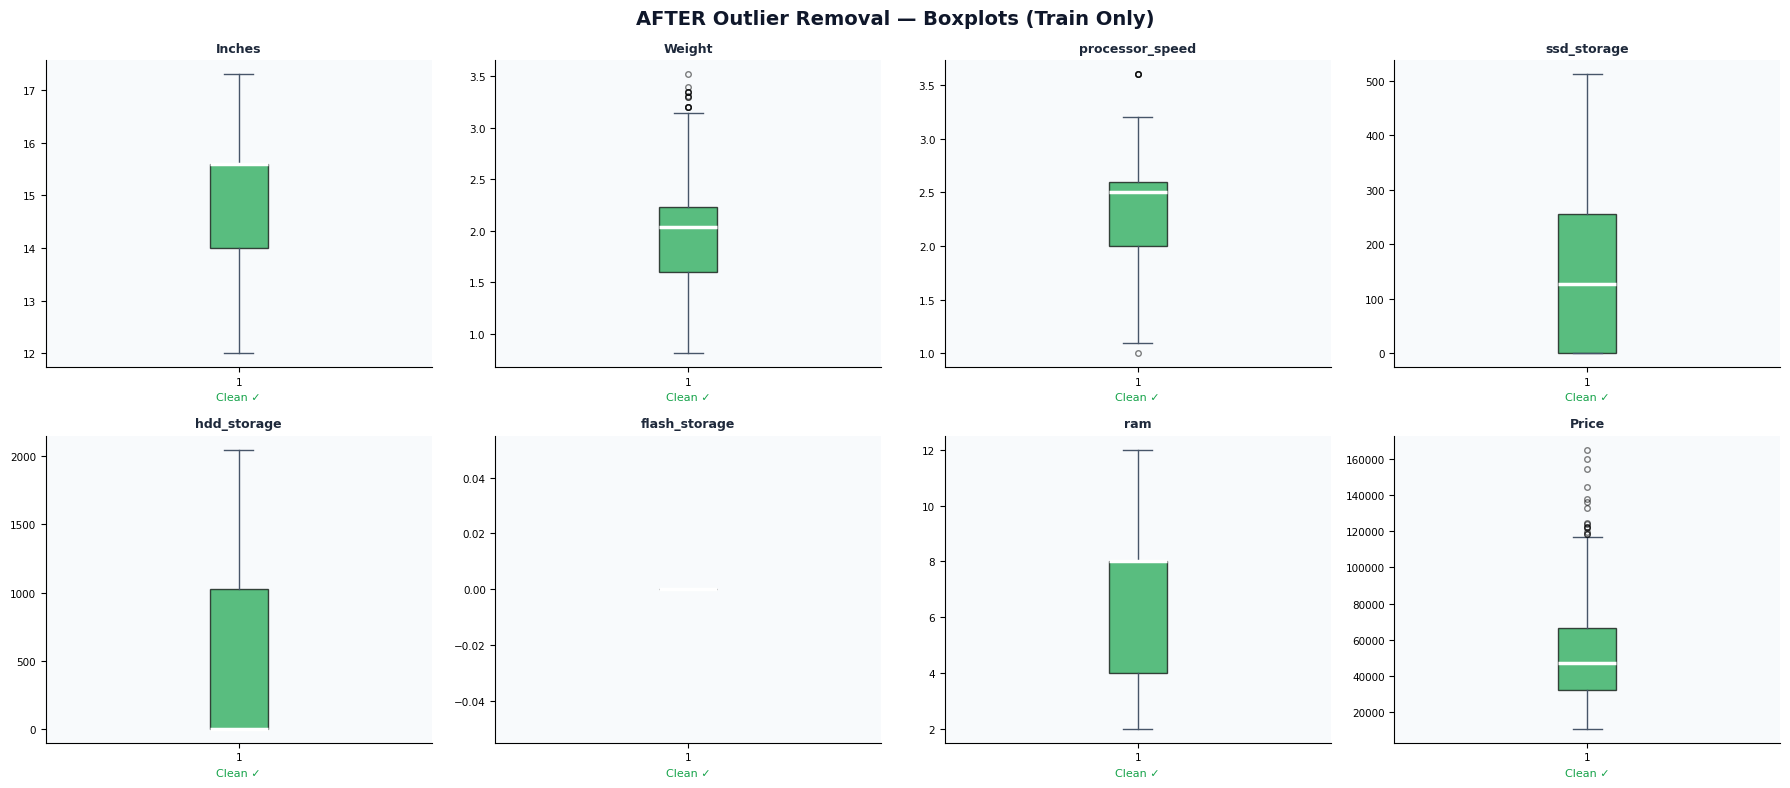


✅ Saved: boxplots_after_num.png


In [74]:
# ══════════════════════════════════════════════════════════════════
# STEP 5 — OUTLIER REMOVAL (IQR drop rows — train only)
#
#  WHY before ColumnTransformer?
#  ColumnTransformer runs sub-pipelines in parallel then hstack()s
#  the results. If one sub-pipeline drops different rows than
#  another the shapes mismatch and it crashes.
#  Solution: drop rows HERE (once, on all cols together),
#  then use IQRClipper inside pipelines to CLIP (not drop) any
#  residual outliers that arrive at inference time.
# ══════════════════════════════════════════════════════════════════
print("\n" + "─"*60)
print("  STEP 5: OUTLIER REMOVAL (IQR — train only, drop rows)")
print("─"*60)

def fit_iqr_bounds(df, cols):
    """Fit IQR bounds on training data only — no data leakage."""
    bounds = {}
    for col in cols:
        s      = df[col].dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR    = Q3 - Q1
        bounds[col] = (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    return bounds

def remove_outliers(df_X, df_y, bounds):
    """Drop rows that fall outside IQR bounds in any column."""
    mask = pd.Series([True] * len(df_X), index=df_X.index)
    for col, (lo, hi) in bounds.items():
        if col in df_X.columns:
            col_mask = df_X[col].isna() | \
                       ((df_X[col] >= lo) & (df_X[col] <= hi))
            mask = mask & col_mask
    return df_X[mask].copy(), df_y[mask].copy()

# Combine features + target so rows are dropped consistently
train_all        = X_train.copy()
train_all[TARGET] = y_train.values

# Fit bounds on train (includes target to remove price outliers too)
bounds = fit_iqr_bounds(train_all, NUM_COLS + [TARGET])

X_train_clean, y_train_clean = remove_outliers(
    train_all[NUM_COLS], train_all[TARGET], bounds
)

removed = len(X_train) - len(X_train_clean)
print(f"\n  Rows before : {len(X_train)}")
print(f"  Rows after  : {len(X_train_clean)}")
print(f"  Removed     : {removed}  ({removed/len(X_train)*100:.1f}% of train)")

print("\n  IQR Bounds used (fitted on train only):")
for col, (lo, hi) in bounds.items():
    print(f"    {col:<22}: [{lo:>10.2f},  {hi:>10.2f}]")

# ── Boxplots AFTER removal
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

after_df         = X_train_clean.copy()
after_df[TARGET] = y_train_clean.values

for i, col in enumerate(all_cols):
    axes[i].boxplot(after_df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#16A34A', alpha=0.7),
                    medianprops=dict(color='white', lw=2.5),
                    flierprops=dict(marker='o', markersize=4,
                                    alpha=0.5, color='#1E293B'),
                    whiskerprops=dict(color='#475569'),
                    capprops=dict(color='#475569'))
    axes[i].set_title(col, fontweight='bold', fontsize=9, color='#1E293B')
    axes[i].set_facecolor('#F8FAFC')
    axes[i].spines[['top','right']].set_visible(False)
    axes[i].tick_params(labelsize=7.5)
    axes[i].set_xlabel("Clean ✓", fontsize=8, color='#16A34A')

fig.suptitle('AFTER Outlier Removal — Boxplots (Train Only)',
             fontsize=14, fontweight='bold', color='#0F172A')
plt.tight_layout()
# plt.savefig('boxplots_after_num.png', dpi=130,
#             bbox_inches='tight', facecolor='#F1F5F9')
plt.show()
print("\n✅ Saved: boxplots_after_num.png")


In [75]:
# ══════════════════════════════════════════════════════════════════
# STEP 6 — CUSTOM TRANSFORMER: IQRClipper
#           Clips values to bounds — safe inside Pipeline
#           because it NEVER changes the number of rows
# ══════════════════════════════════════════════════════════════════
class IQRClipper(BaseEstimator, TransformerMixin):
    """
    Clips values to [Q1 - 1.5*IQR, Q3 + 1.5*IQR].
    Safe inside Pipeline/ColumnTransformer — no row drops.
    Protects pipeline from unseen outliers at inference time.
    """
    def __init__(self, multiplier=1.5):
        self.multiplier = multiplier
        self.bounds_    = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        for col in X.columns:
            s      = X[col].dropna()
            Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
            IQR    = Q3 - Q1
            self.bounds_[col] = (Q1 - self.multiplier * IQR,
                                  Q3 + self.multiplier * IQR)
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            lo, hi = self.bounds_[col]
            X[col] = X[col].clip(lower=lo, upper=hi)
        return X.values

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.array(input_features)
        return np.array([str(i) for i in range(len(self.bounds_))])


In [76]:
# ══════════════════════════════════════════════════════════════════
# STEP 7 — BUILD PIPELINES + COLUMN TRANSFORMER
# ══════════════════════════════════════════════════════════════════
print("\n" + "─"*60)
print("  STEP 7: PIPELINES + COLUMN TRANSFORMER")
print("─"*60)

# Column grouping rationale:
#   Inches / Weight / processor_speed  → continuous, near-normal → StandardScaler
#   ssd / hdd / flash                  → skewed, many zeros       → RobustScaler
#   ram                                → power-of-2, [4..64]      → MinMaxScaler

continuous_cols = ['Inches', 'Weight', 'processor_speed']
storage_cols    = ['ssd_storage', 'hdd_storage', 'flash_storage']
ram_cols        = ['ram']

print(f"\n  continuous → StandardScaler : {continuous_cols}")
print(f"  storage    → RobustScaler   : {storage_cols}")
print(f"  ram        → MinMaxScaler   : {ram_cols}")

# ── Pipeline A: Continuous ────────────────────────────────────────
continuous_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # fill NaN → median
    ('clipper', IQRClipper(multiplier=1.5)),         # clip residual outliers
    ('scaler',  StandardScaler()),                   # mean=0, std=1
])

# ── Pipeline B: Storage (skewed + many zeros) ─────────────────────
storage_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # fill NaN → median
    ('clipper', IQRClipper(multiplier=1.5)),         # clip residual outliers
    ('scaler',  RobustScaler()),                     # IQR-based, outlier robust
])

# ── Pipeline C: RAM (bounded discrete values) ─────────────────────
ram_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # fill NaN → median
    ('clipper', IQRClipper(multiplier=1.5)),         # clip residual outliers
    ('scaler',  MinMaxScaler()),                     # scale to [0, 1]
])

# ── Column Transformer ────────────────────────────────────────────
numerical_preprocessor = ColumnTransformer(
    transformers=[
        ('continuous', continuous_pipeline, continuous_cols),
        ('storage',    storage_pipeline,    storage_cols),
        ('ram',        ram_pipeline,        ram_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=True
)

print("""
  ┌──────────────────────────────────────────────────────────┐
  │              ColumnTransformer                           │
  │  ┌─────────────┐  ┌─────────────┐  ┌─────────────┐      │
  │  │ continuous  │  │   storage   │  │     ram     │      │
  │  │─────────────│  │─────────────│  │─────────────│      │
  │  │ Imputer     │  │ Imputer     │  │ Imputer     │      │
  │  │ IQRClipper  │  │ IQRClipper  │  │ IQRClipper  │      │
  │  │ StandardScl │  │ RobustScl   │  │ MinMaxScl   │      │
  └──────────────────────────────────────────────────────────┘
""")



────────────────────────────────────────────────────────────
  STEP 7: PIPELINES + COLUMN TRANSFORMER
────────────────────────────────────────────────────────────

  continuous → StandardScaler : ['Inches', 'Weight', 'processor_speed']
  storage    → RobustScaler   : ['ssd_storage', 'hdd_storage', 'flash_storage']
  ram        → MinMaxScaler   : ['ram']

  ┌──────────────────────────────────────────────────────────┐
  │              ColumnTransformer                           │
  │  ┌─────────────┐  ┌─────────────┐  ┌─────────────┐      │
  │  │ continuous  │  │   storage   │  │     ram     │      │
  │  │─────────────│  │─────────────│  │─────────────│      │
  │  │ Imputer     │  │ Imputer     │  │ Imputer     │      │
  │  │ IQRClipper  │  │ IQRClipper  │  │ IQRClipper  │      │
  │  │ StandardScl │  │ RobustScl   │  │ MinMaxScl   │      │
  └──────────────────────────────────────────────────────────┘



In [77]:
# ══════════════════════════════════════════════════════════════════
# STEP 8 — FIT & TRANSFORM
# ══════════════════════════════════════════════════════════════════
print("\n" + "─"*60)
print("  STEP 8: FIT & TRANSFORM")
print("─"*60)

print(f"\n  Fitting on X_train_clean {X_train_clean.shape} ...")
X_train_scaled = numerical_preprocessor.fit_transform(X_train_clean)
X_test_scaled  = numerical_preprocessor.transform(X_test)

feature_names = numerical_preprocessor.get_feature_names_out()

print(f"\n  X_train_clean → X_train_scaled : {X_train_clean.shape} → {X_train_scaled.shape}")
print(f"  X_test        → X_test_scaled  : {X_test.shape}        → {X_test_scaled.shape}")

print(f"\n── Feature names ({len(feature_names)}) ──────────────────────────────")
for i, n in enumerate(feature_names, 1):
    print(f"  {i}. {n}")


────────────────────────────────────────────────────────────
  STEP 8: FIT & TRANSFORM
────────────────────────────────────────────────────────────

  Fitting on X_train_clean (744, 7) ...

  X_train_clean → X_train_scaled : (744, 7) → (744, 7)
  X_test        → X_test_scaled  : (249, 7)        → (249, 7)

── Feature names (7) ──────────────────────────────
  1. continuous__Inches
  2. continuous__Weight
  3. continuous__processor_speed
  4. storage__ssd_storage
  5. storage__hdd_storage
  6. storage__flash_storage
  7. ram__ram


In [78]:
# ══════════════════════════════════════════════════════════════════
# STEP 9 — VERIFY SCALING
# ══════════════════════════════════════════════════════════════════
print("\n" + "─"*60)
print("  STEP 9: VERIFICATION")
print("─"*60)

train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)
print("\n── Stats after scaling (train) ──────────────────────────")
print(train_scaled_df.describe().round(3).to_string())

print("\n── Scaler checks ────────────────────────────────────────")
print("  StandardScaler  → mean≈0, std≈1")
for col in [c for c in feature_names if 'continuous__' in c]:
    print(f"    {col.split('__')[-1]:<22} "
          f"mean={train_scaled_df[col].mean():>7.4f}  "
          f"std={train_scaled_df[col].std():.4f}")

print("\n  MinMaxScaler    → range [0.0, 1.0]")
for col in [c for c in feature_names if 'ram__' in c]:
    print(f"    {col.split('__')[-1]:<22} "
          f"min={train_scaled_df[col].min():.4f}  "
          f"max={train_scaled_df[col].max():.4f}")


────────────────────────────────────────────────────────────
  STEP 9: VERIFICATION
────────────────────────────────────────────────────────────

── Stats after scaling (train) ──────────────────────────
       continuous__Inches  continuous__Weight  continuous__processor_speed  storage__ssd_storage  storage__hdd_storage  storage__flash_storage  ram__ram
count             744.000             744.000                      744.000               744.000               744.000                   744.0   744.000
mean                0.000               0.000                       -0.000                 0.091                 0.410                     0.0     0.473
std                 1.001               1.001                        1.001                 0.550                 0.503                     0.0     0.203
min                -2.471              -2.422                       -2.633                -0.500                 0.000                     0.0     0.000
25%                -0.837     

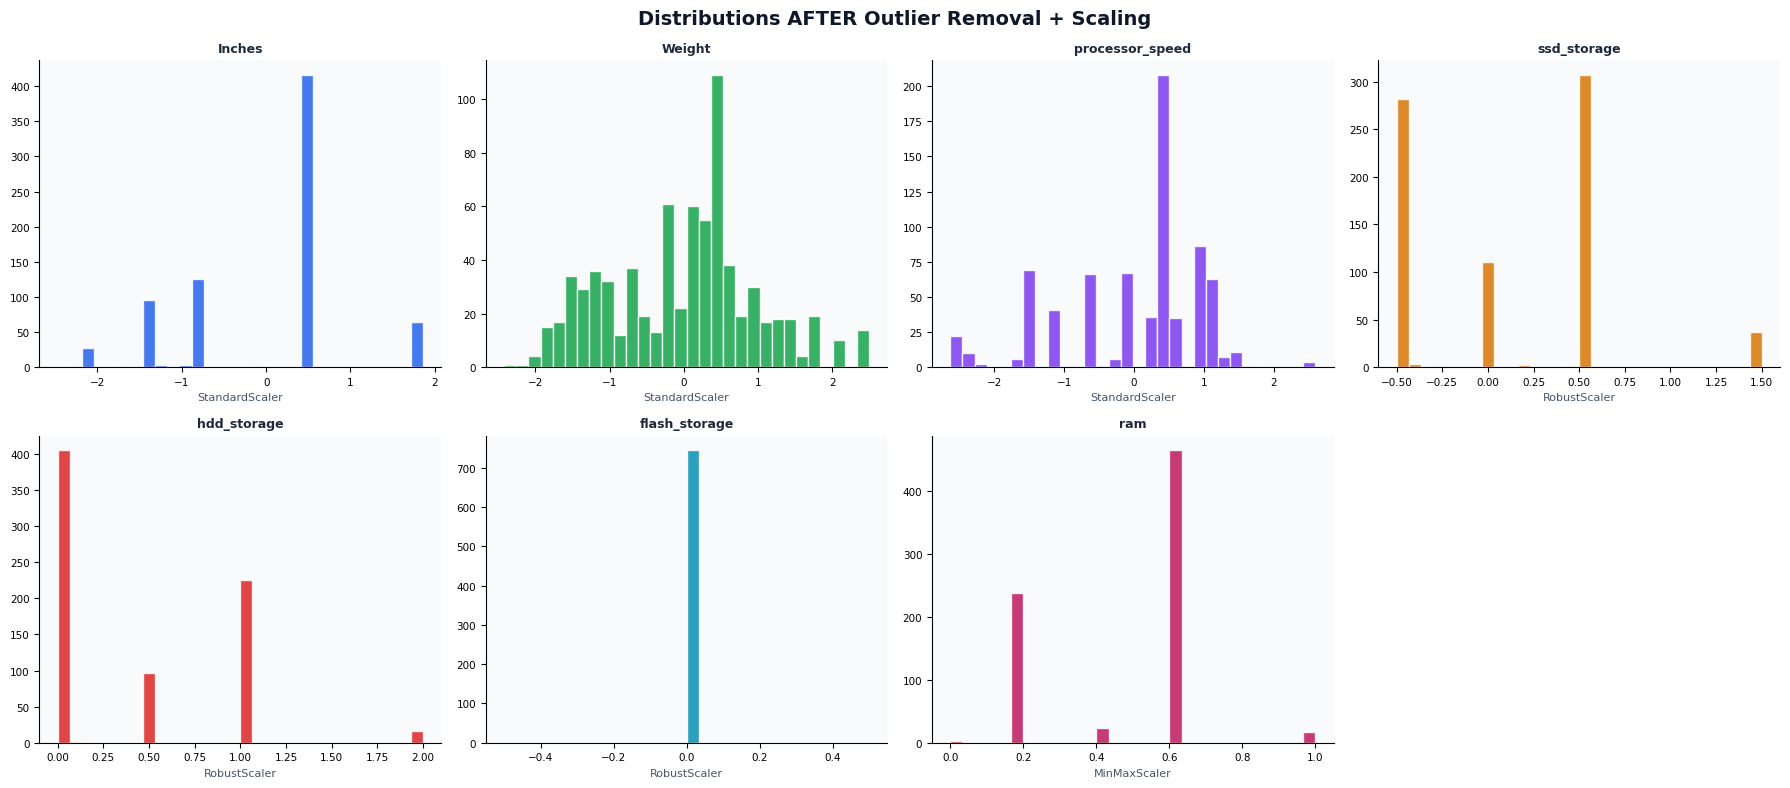


✅ Saved: distributions_after_scaling.png


In [79]:
# ══════════════════════════════════════════════════════════════════
# STEP 10 — DISTRIBUTIONS AFTER SCALING
# ══════════════════════════════════════════════════════════════════
colors = ['#2563EB','#16A34A','#7C3AED',
          '#D97706','#DC2626','#0891B2','#BE185D']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(feature_names):
    axes[i].hist(train_scaled_df[col].dropna(), bins=30,
                 color=colors[i % len(colors)],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col.split('__')[-1], fontweight='bold',
                      fontsize=9, color='#1E293B')
    axes[i].set_facecolor('#F8FAFC')
    axes[i].spines[['top','right']].set_visible(False)
    axes[i].tick_params(labelsize=7.5)
    scaler_label = ('StandardScaler' if 'continuous__' in col
                    else 'RobustScaler'  if 'storage__'   in col
                    else 'MinMaxScaler')
    axes[i].set_xlabel(scaler_label, fontsize=8, color='#475569')

for j in range(len(feature_names), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distributions AFTER Outlier Removal + Scaling',
             fontsize=14, fontweight='bold', color='#0F172A')
plt.tight_layout()
# plt.savefig('distributions_after_scaling.png', dpi=130,
#             bbox_inches='tight', facecolor='#F1F5F9')
plt.show()
print("\n✅ Saved: distributions_after_scaling.png")

In [80]:
# ══════════════════════════════════════════════════════════════════
# STEP 11 — COMBINE WITH CATEGORICAL PIPELINE (hook)
# ══════════════════════════════════════════════════════════════════
print("\n" + "─"*60)
print("  STEP 11: FULL PIPELINE HOOK")
print("─"*60)
print("""
  full_preprocessor = ColumnTransformer(transformers=[
      # ── categorical (from categorical_pipeline.py) ─────────
      ('display',    display_pipeline,    ['display_type']),
      ('company',    company_pipeline,    ['Company']),
      ('typename',   typename_pipeline,   ['TypeName']),
      ('proc_brand', proc_brand_pipeline, ['processor_brand']),
      ('proc_type',  proc_type_pipeline,  ['processor_type']),
      ('os',         os_pipeline,         ['os']),
      # ── numerical (this file) ──────────────────────────────
      ('continuous', continuous_pipeline, ['Inches','Weight','processor_speed']),
      ('storage',    storage_pipeline,    ['ssd_storage','hdd_storage','flash_storage']),
      ('ram',        ram_pipeline,        ['ram']),
  ])

  full_pipeline = Pipeline(steps=[
      ('preprocessor', full_preprocessor),
      ('model',        RandomForestRegressor()),
  ])

  full_pipeline.fit(X_train_clean, y_train_clean)
  full_pipeline.predict(X_test)
""")

# ══════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════
print("=" * 60)
print("  NUMERICAL PIPELINE — FINAL SUMMARY")
print("=" * 60)
print(f"""
  Step 1   Inspection         Descriptive stats + missing values
  Step 2   Outlier Detection  IQR report + Z-score report
  Step 3   Visualise          Boxplots BEFORE removal
  Step 4   Train/Test Split   80/20, random_state=42
  Step 5   Outlier Removal    IQR drop rows — train only
             Removed : {removed} rows ({removed/len(X_train)*100:.1f}% of train)
  Step 6   IQRClipper         Custom transformer (clip only, safe in pipeline)
  Step 7   ColumnTransformer  3 sub-pipelines:
             continuous  → Impute → IQRClip → StandardScaler
             storage     → Impute → IQRClip → RobustScaler
             ram         → Impute → IQRClip → MinMaxScaler
  Step 8   Fit & Transform
             X_train_scaled : {X_train_scaled.shape}
             X_test_scaled  : {X_test_scaled.shape}
  Step 9   Verify            mean/std/range checks
  Step 10  Visualise         Distributions AFTER scaling
  Step 11  Hook              Ready to join categorical pipeline

  Scaler rationale:
    Inches/Weight/CPU   StandardScaler  near-normal distribution
    SSD/HDD/Flash       RobustScaler    skewed + many zeros
    RAM                 MinMaxScaler    discrete [4, 8, 16, 32, 64]
""")
print("✅ Numerical pipeline complete!")





────────────────────────────────────────────────────────────
  STEP 11: FULL PIPELINE HOOK
────────────────────────────────────────────────────────────

  full_preprocessor = ColumnTransformer(transformers=[
      # ── categorical (from categorical_pipeline.py) ─────────
      ('display',    display_pipeline,    ['display_type']),
      ('company',    company_pipeline,    ['Company']),
      ('typename',   typename_pipeline,   ['TypeName']),
      ('proc_brand', proc_brand_pipeline, ['processor_brand']),
      ('proc_type',  proc_type_pipeline,  ['processor_type']),
      ('os',         os_pipeline,         ['os']),
      # ── numerical (this file) ──────────────────────────────
      ('continuous', continuous_pipeline, ['Inches','Weight','processor_speed']),
      ('storage',    storage_pipeline,    ['ssd_storage','hdd_storage','flash_storage']),
      ('ram',        ram_pipeline,        ['ram']),
  ])

  full_pipeline = Pipeline(steps=[
      ('preprocessor', full_preprocessor),
   

In [82]:
full_preprocessor = ColumnTransformer(transformers=[
      # ── categorical (from categorical_pipeline.py) ─────────
      ('display',    display_pipeline,    ['display_type']),
      ('company',    company_pipeline,    ['Company']),
      ('typename',   typename_pipeline,   ['TypeName']),
      ('proc_brand', proc_brand_pipeline, ['processor_brand']),
      ('proc_type',  proc_type_pipeline,  ['processor_type']),
      ('os',         os_pipeline,         ['os']),
      # ── numerical (this file) ──────────────────────────────
      ('continuous', continuous_pipeline, ['Inches','Weight','processor_speed']),
      ('storage',    storage_pipeline,    ['ssd_storage','hdd_storage','flash_storage']),
      ('ram',        ram_pipeline,        ['ram']),
  ])

In [83]:
from sklearn.linear_model import LinearRegression
full_pipeline = Pipeline(steps=[
      ('preprocessor', full_preprocessor),
      ('model',        LinearRegression()),
  ])

In [103]:
x = df.drop('Price', axis=1)
y = df['Price']

In [104]:
y = np.log2(y)

In [106]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=33)

In [107]:
full_pipeline.fit(x_train, y_train)
ypred = full_pipeline.predict(x_test)


  [RareCategoryGrouper] '0' — threshold=10
    Kept  : ['Acer', 'Apple', 'Asus', 'Dell', 'HP', 'Lenovo', 'MSI', 'Toshiba']
    Rare→Other: ['Chuwi', 'Fujitsu', 'Google', 'Huawei', 'LG', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Xiaomi'] (10 categories)

  [RareCategoryGrouper] '0' — threshold=10
    Kept  : ['AMD', 'Intel']
    Rare→Other: ['Samsung'] (1 categories)

  [ProcessorFamilyGrouper] '0': 88 unique → 11 families
    Families: ['AMD Other', 'Atom', 'Celeron', 'Core M', 'Core i3', 'Core i5', 'Core i7', 'Other', 'Pentium', 'Ryzen', 'Xeon']

  [ProcessorFamilyGrouper] '0': 48 unique → 10 families
    Families: ['AMD Other', 'Atom', 'Celeron', 'Core M', 'Core i3', 'Core i5', 'Core i7', 'Pentium', 'Ryzen', 'Xeon']


In [109]:
yPred = 2 ** ypred

In [110]:
df['Price'].head()

0     71378.6832
1     47895.5232
2     30636.0000
3    135195.3360
4     96095.8080
Name: Price, dtype: float64

In [112]:
from sklearn.metrics import root_mean_squared_error, r2_score

rmse = root_mean_squared_error(y_test, ypred)
r2 = r2_score(y_test, ypred)

In [116]:
import dagshub
import mlflow
dagshub.init(repo_owner='shahriar0999', repo_name='Laptop-Price-Prediction-using-Machine-Learning', mlflow=True)
mlflow.set_tracking_uri("https://dagshub.com/shahriar0999/Laptop-Price-Prediction-using-Machine-Learning.mlflow")
mlflow.set_experiment("Logistic Regression Baseline")

Initialized MLflow to track repo "shahriar0999/Laptop-Price-Prediction-using-Machine-Learning"

Repository shahriar0999/Laptop-Price-Prediction-using-Machine-Learning initialized!

2026/03/06 10:43:42 INFO mlflow.tracking.fluent: Experiment with name 'Logistic Regression Baseline' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/6c9627ee0ca345959273474cb2c0ce25', creation_time=1772772222909, experiment_id='1', last_update_time=1772772222909, lifecycle_stage='active', name='Logistic Regression Baseline', tags={}, workspace='default'>

In [117]:
x_train.shape

(993, 14)

In [119]:
with mlflow.start_run():
    
    # Log preprocessing parameters
    mlflow.log_param("num_features", 14)
    mlflow.log_param("test_size", 0.2)
    
    # Model building and training
    full_pipeline.fit(x_train, y_train)
    
    
    # Log model parameters
    mlflow.log_param("model", "Linear Regression")
    
    # Model evaluation
    y_pred = full_pipeline.predict(x_test)
    rmse = root_mean_squared_error(y_test, ypred)
    r2 = r2_score(y_test, ypred)    
    
    # Log evaluation metrics
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2_SCORE", r2)
    
    import joblib

    # Save the model locally
    joblib.dump(full_pipeline, "full_pipeline.pkl")

    # Log the model as an artifact
    mlflow.log_artifact("full_pipeline.pkl")


    # Save and log the notebook
    import os
    notebook_path = "exp1_baseline_model.ipynb"
    os.system(f"jupyter nbconvert --to notebook --execute --inplace {notebook_path}")
    mlflow.log_artifact(notebook_path)
    
    # Print the results for verification
    print(f"rmse: {rmse}")
    print(f"r2_score: {r2}")



  [RareCategoryGrouper] '0' — threshold=10
    Kept  : ['Acer', 'Apple', 'Asus', 'Dell', 'HP', 'Lenovo', 'MSI', 'Toshiba']
    Rare→Other: ['Chuwi', 'Fujitsu', 'Google', 'Huawei', 'LG', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Xiaomi'] (10 categories)

  [RareCategoryGrouper] '0' — threshold=10
    Kept  : ['AMD', 'Intel']
    Rare→Other: ['Samsung'] (1 categories)

  [ProcessorFamilyGrouper] '0': 88 unique → 11 families
    Families: ['AMD Other', 'Atom', 'Celeron', 'Core M', 'Core i3', 'Core i5', 'Core i7', 'Other', 'Pentium', 'Ryzen', 'Xeon']

  [ProcessorFamilyGrouper] '0': 48 unique → 10 families
    Families: ['AMD Other', 'Atom', 'Celeron', 'Core M', 'Core i3', 'Core i5', 'Core i7', 'Pentium', 'Ryzen', 'Xeon']
rmse: 0.38228538624314606
r2_score: 0.81478763924771
🏃 View run enchanting-boar-441 at: https://dagshub.com/shahriar0999/Laptop-Price-Prediction-using-Machine-Learning.mlflow/#/experiments/1/runs/b07f9ec272024e62a1958d70bf650fca
🧪 View experiment at: https://dagshub.

In [120]:
with mlflow.start_run():
    
    # Log preprocessing parameters
    mlflow.log_param("num_features", 14)
    mlflow.log_param("test_size", 0.2)
    
    # Model building and training
    full_pipeline.fit(x_train, y_train)
    
    # Log model parameters
    mlflow.log_param("model", "Linear Regression")
    
    # Model evaluation
    y_pred = full_pipeline.predict(x_test)
    rmse = root_mean_squared_error(y_test, y_pred)  # ✅ fixed typo
    r2 = r2_score(y_test, y_pred)                   # ✅ fixed typo
    
    # Log evaluation metrics
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2_SCORE", r2)
    
    # ✅ Log model properly in the model section
    mlflow.sklearn.log_model(full_pipeline, "full_pipeline")

    # Save and log the notebook
    import os
    notebook_path = "exp1_baseline_model.ipynb"
    os.system(f"jupyter nbconvert --to notebook --execute --inplace {notebook_path}")
    mlflow.log_artifact(notebook_path)
    
    # Print the results for verification
    print(f"rmse: {rmse}")
    print(f"r2_score: {r2}")


  [RareCategoryGrouper] '0' — threshold=10
    Kept  : ['Acer', 'Apple', 'Asus', 'Dell', 'HP', 'Lenovo', 'MSI', 'Toshiba']
    Rare→Other: ['Chuwi', 'Fujitsu', 'Google', 'Huawei', 'LG', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Xiaomi'] (10 categories)

  [RareCategoryGrouper] '0' — threshold=10
    Kept  : ['AMD', 'Intel']
    Rare→Other: ['Samsung'] (1 categories)

  [ProcessorFamilyGrouper] '0': 88 unique → 11 families
    Families: ['AMD Other', 'Atom', 'Celeron', 'Core M', 'Core i3', 'Core i5', 'Core i7', 'Other', 'Pentium', 'Ryzen', 'Xeon']

  [ProcessorFamilyGrouper] '0': 48 unique → 10 families
    Families: ['AMD Other', 'Atom', 'Celeron', 'Core M', 'Core i3', 'Core i5', 'Core i7', 'Pentium', 'Ryzen', 'Xeon']


2026/03/06 10:54:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/06 10:54:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rmse: 0.38228538624314606
r2_score: 0.81478763924771
🏃 View run fearless-kite-575 at: https://dagshub.com/shahriar0999/Laptop-Price-Prediction-using-Machine-Learning.mlflow/#/experiments/1/runs/9d24b0ac74214b6fbe7b6460a5ba77a4
🧪 View experiment at: https://dagshub.com/shahriar0999/Laptop-Price-Prediction-using-Machine-Learning.mlflow/#/experiments/1
